In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.linear_model as LinearRegression


In [2]:
# ============================================================
# COST FUNCTION
# ============================================================

def cost_function(size, price, w, b):
    m = len(size)
    cost = 0

    for x, y in zip(size, price):
        prediction = w * x + b
        cost += (prediction - y) ** 2

    return cost / (2 * m)

In [3]:
# ============================================================
# DATASET
# ============================================================

size = [100, 120, 140, 80, 300, 125, 105, 200,
        90, 45, 110, 204, 392, 493, 90, 21]

price = [190, 250, 300, 120, 400, 250, 200, 350,
         150, 80, 220, 400, 600, 700, 150, 50]


# Sort according to size
pairs = sorted(zip(size, price))

size = [x for x, _ in pairs]
price = [y for _, y in pairs]

In [5]:
# ============================================================
# METHOD 1: BRUTE FORCE
# ============================================================

best_w = 0
best_b = 0
lowest_cost = float("inf")

for w in np.arange(-10, 10, 0.1):

    for b in np.arange(-500, 500, 1):

        current_cost = cost_function(size, price, w, b)

        if current_cost < lowest_cost:

            lowest_cost = current_cost
            best_w = w
            best_b = b

print("Brute Force")
print("Best w =", best_w)
print("Best b =", best_b)
print("Lowest Cost =", lowest_cost)

Brute Force
Best w = 1.3999999999999595
Best b = 47
Lowest Cost = 650.0687499999775


In [6]:
# ============================================================
# METHOD 2: GRADIENT DESCENT USING PYTHON LOOPS
# ============================================================

alpha = 1e-7
epochs = 10000

w = 0
b = 0

for _ in range(epochs):

    dw = 0
    db = 0

    for x, y in zip(size, price):

        prediction = w * x + b
        error = prediction - y

        dw += error * x
        db += error

    dw /= len(size)
    db /= len(size)

    # Parallel update
    w -= alpha * dw
    b -= alpha * db


best_w = w
best_b = b

lowest_cost = cost_function(
    size,
    price,
    best_w,
    best_b
)

print("Gradient Descent (Python Loops)")
print("Best w =", best_w)
print("Best b =", best_b)
print("Lowest Cost =", lowest_cost)



Gradient Descent (Python Loops)
Best w = 1.5685022966033653
Best b = 0.025317674356397674
Lowest Cost = 1144.652643276179


In [7]:
# ============================================================
# METHOD 3: GRADIENT DESCENT USING NUMPY
# ============================================================

X = np.array(size)
y = np.array(price)

alpha = 1e-7
epochs = 10000

w = 0
b = 0

for _ in range(epochs):

    # Prediction for all training examples
    prediction = w * X + b

    # Error for all examples
    error = prediction - y

    # Gradients
    dw = np.mean(error * X)
    db = np.mean(error)

    # Parallel update
    w -= alpha * dw
    b -= alpha * db


best_w = w
best_b = b

# Final cost
prediction = best_w * X + best_b
lowest_cost = np.mean((prediction - y) ** 2) / 2

print("\nGradient Descent (NumPy)")
print("Best w =", best_w)
print("Best b =", best_b)
print("Lowest Cost =", lowest_cost)




Gradient Descent (NumPy)
Best w = 1.5685022966033653
Best b = 0.025317674356397677
Lowest Cost = 1144.6526432761793


In [8]:
# ============================================================
# PREDICTIONS
# ============================================================

predictions = best_w * X + best_b

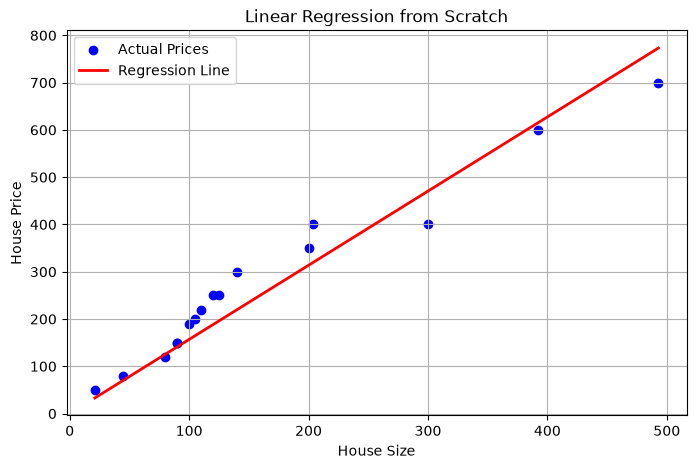

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(size,price,color="blue",label="Actual Prices")
plt.plot(size,predictions,color="red",linewidth=2,label="Regression Line")
plt.xlabel("House Size")
plt.ylabel("House Price")
plt.title("Linear Regression from Scratch")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
X = np.array(size).reshape(-1, 1)
y = np.array(price)

model = LinearRegression.LinearRegression()

model.fit(X, y)

print("\nScikit-Learn")
print("Best w =", model.coef_[0])
print("Best b =", model.intercept_)

predictions = model.predict(X)

print("Cost =", np.mean((predictions - y) ** 2) / 2)


Scikit-Learn
Best w = 1.3661608579694708
Best b = 52.343084775614614
Cost = 641.1496930349654


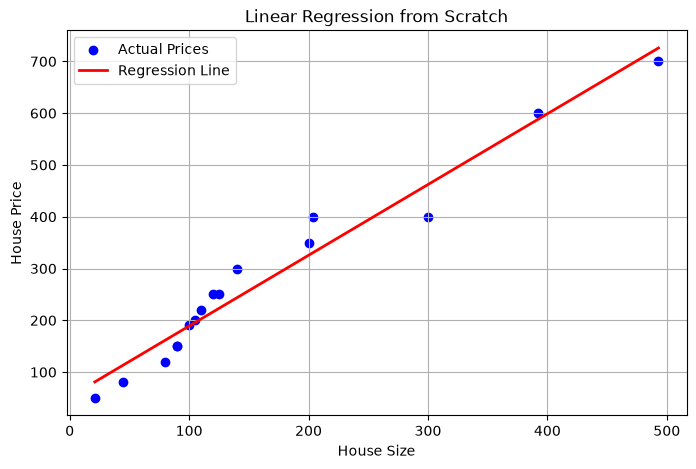

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(size,price,color="blue",label="Actual Prices")
plt.plot(size,predictions,color="red",linewidth=2,label="Regression Line")
plt.xlabel("House Size")
plt.ylabel("House Price")
plt.title("Linear Regression from Scratch")
plt.legend()
plt.grid(True)
plt.show()